This script plots various aspects of the TrappedResonance objective function

In [1]:
import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [6]:
# User Inputs #
eq = desc.io.load("equil_G1600_DESC_fixed.h5")

rhos = (np.linspace(0.1,0.9,100))**(1/2) # rho = sqrt(s)
alphas = np.linspace(0,2*np.pi,3)
KE_frac = np.array([0.001])
pitch_invs = jnp.linspace(6.0,6.1,1)
N=0 # QA

In [7]:
# Run objective function
obj = TrappedResonance(eq,rho=rhos,pitch_invs=pitch_invs,KE_frac=KE_frac,alpha=alphas,N=N)
obj.build()
obj_out = obj.compute(eq.params_dict) # when not flattened, this shape is (rho,pitch,energy)

Precomputing transforms


In [8]:
# testing
res=obj_out['res']
obj=obj_out['obj']
obj_test = obj_out['obj_test']
omega = obj_out['omega']
print(res[:,0,0,0])
print(omega[:,0,0,0])
print(obj_test[:,0,0,0])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[-7.03073178e-03 -6.79870487e-03 -7.05417060e-03 -7.57053676e-03
 -7.42884560e-03 -6.68336318e-03 -5.98776935e-03 -5.39090476e-03
 -4.95692329e-03 -4.69606999e-03 -4.52047064e-03 -4.31721124e-03
 -4.00809398e-03 -3.61204131e-03 -3.22208674e-03 -2.90837952e-03
 -2.68169012e-03 -2.51958268e-03 -2.40053784e-03 -2.30549678e-03
 -2.22108856e-03 -2.14051462e-03 -2.05784397e-03 -1.97316700e-03
 -1.88688164e-03 -1.80049551e-03 -1.71746260e-03 -1.63922056e-03
 -1.56670976e-03 -1.50026943e-03 -1.43992381e-03 -1.38537900e-03
 -1.33579397e-03 -1.29018625e-03 -1.24756865e-03 -1.20707701e-03
 -1.16798302e-03 -1.12974332e-03 -1.09191331e-03 -1.05397597e-03
 -1.01547173e-03 -9.76290792e-04 -9.36806413

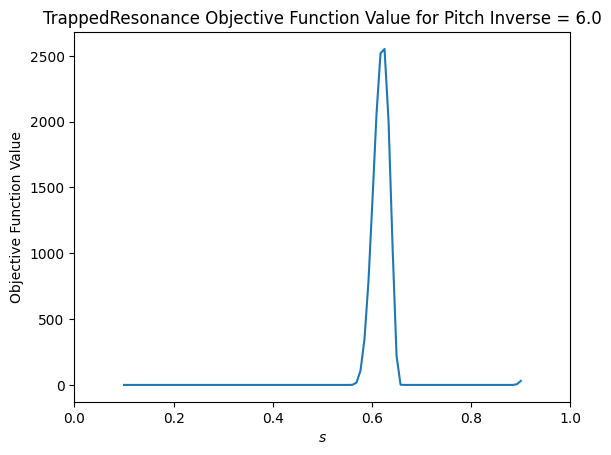

In [9]:
# Plot s vs. obj_out for each pitch inverse
obj_out = obj
for i in range(0,obj_out.shape[1]): # loop through each pitch angle
    plt.figure(i+1)
    plt.plot(rhos**2,obj_out[:,i,0]) # assuming we are only doing 1 energy for now
    plt.xlabel(r'$s$')
    plt.ylabel('Objective Function Value')
    plt.title('TrappedResonance Objective Function Value for Pitch Inverse = '+str(pitch_invs[i]))
    # plt.ylabel(r'$\omega_{\zeta}$')
    # plt.title(r'$\omega_{\zeta}$ Value for Pitch Inverse = '+str(pitch_invs[i]))
    plt.xlim([0.0,1.0])

In [ ]:
# Plot the value of the TrappedResonance objective (summing over the rho axis) vs. pitch
num_valid_pitch = jnp.sum(obj_out!=0,axis=1)
obj_out_rhosum = np.sum(obj_out,axis=0) / num_valid_pitch # average over rho axis where the obj function is not zero

plt.figure()
plt.plot(pitch_invs,obj_out_rhosum[:,0])
plt.title("TrappedResonance Objective Function Averaged Over All Surfaces")
plt.xlabel("Pitch Inverse [T]")
plt.ylabel("Objective Function Value")

In [ ]:
x=np.array([0,1,2,0])
mask = x!=0
count = jnp.sum(mask,axis=0) # how many wells that are not 0
print(count)